In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [2]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# These are the base models — each one looks at the data differently
# The meta-model then learns how to best combine their predictions
base_models = [
    ('lr',  LogisticRegression(max_iter=500, random_state=42)),
    ('rf',  RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)),
    ('gb',  GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                        learning_rate=0.05, random_state=42)),
    ('svc', SVC(probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
]

print('Base models defined ✅')

Base models defined ✅


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

# ── Load Data ──────────────────────────────────────────────
train = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/titanic/test.csv')

if 'Survived' in test.columns:
    test = test.drop(columns=['Survived'])

test_ids = test['PassengerId'].copy()
dfs = [train, test]

# ── Feature Engineering ────────────────────────────────────
for df in dfs:
    df['Title'] = df['Name'].str.extract(r',\s*([^.]+)\.', expand=False).str.strip()
    rare = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
    df['Title'] = df['Title'].replace(rare, 'Rare')
    df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Ms':'Miss', 'Mme':'Mrs'})
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone']  = (df['FamilySize'] == 1).astype(int)
    df['HasCabin'] = df['Cabin'].notna().astype(int)

# ── Fill Missing Values ────────────────────────────────────
age_medians = train.groupby('Title')['Age'].median()
fallback_age = age_medians.get('Rare', age_medians.median())

for df in dfs:
    df['Age'] = df.apply(
        lambda row: age_medians.get(row['Title'], fallback_age)
        if pd.isnull(row['Age']) else row['Age'],
        axis=1
    )
    df['Fare'] = df.groupby('Pclass')['Fare'].transform(
        lambda x: x.fillna(x.median())
    )
    df['Embarked'] = df['Embarked'].fillna(train['Embarked'].mode()[0])
    df['AgeBand'] = pd.cut(
        df['Age'], bins=[0,12,18,35,60,100], labels=[0,1,2,3,4]
    ).astype(int)
    df['FareBand'] = pd.qcut(
        df['Fare'], q=4, labels=[0,1,2,3]
    ).astype(int)

# ── Encode Categoricals ────────────────────────────────────
le_title = LabelEncoder()
combined_titles = pd.concat([train['Title'], test['Title']])
le_title.fit(combined_titles)
train['Title'] = le_title.transform(train['Title'])
test['Title']  = le_title.transform(test['Title'])

le_sex = LabelEncoder()
le_sex.fit(train['Sex'])
train['Sex'] = le_sex.transform(train['Sex'])
test['Sex']  = le_sex.transform(test['Sex'])

le_emb = LabelEncoder()
le_emb.fit(train['Embarked'])
train['Embarked'] = le_emb.transform(train['Embarked'])
test['Embarked']  = le_emb.transform(test['Embarked'])

# ── Feature Matrix ─────────────────────────────────────────
FEATURES = ['Pclass', 'Sex', 'AgeBand', 'FareBand',
            'Embarked', 'Title', 'FamilySize', 'IsAlone', 'HasCabin']

X      = train[FEATURES]
y      = train['Survived']
X_test = test[FEATURES]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('Everything ready!')
print(f'   X shape       : {X.shape}')
print(f'   X_test shape  : {X_test.shape}')
print(f'   Nulls in X    : {X.isnull().sum().sum()}')
print(f'   Nulls in Xtest: {X_test.isnull().sum().sum()}')
print(f'   Train titles  : {sorted(train["Title"].unique())}')
print(f'   Test titles   : {sorted(test["Title"].unique())}')

Everything ready!
   X shape       : (891, 9)
   X_test shape  : (418, 9)
   Nulls in X    : 0
   Nulls in Xtest: 0
   Train titles  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
   Test titles   : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [4]:
# Meta-model: learns which base model to trust most for each pattern
meta_model = LogisticRegression(max_iter=500)

stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,            # base models are trained on CV folds to avoid overfitting
    passthrough=False # set True to also pass original features to meta-model
)

scores = cross_val_score(stacking_clf, X, y, cv=cv, scoring='accuracy')
print(f'Stacking Classifier CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}')
print(f'Individual fold scores: {scores.round(4)}')

Stacking Classifier CV Accuracy: 0.8283 ± 0.0077
Individual fold scores: [0.8324 0.8146 0.8258 0.8315 0.8371]


In [5]:
all_models = {
    'Logistic Regression' : LogisticRegression(max_iter=500, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                        learning_rate=0.05, random_state=42),
    'SVC'                 : SVC(probability=True, random_state=42),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Stacking'            : stacking_clf,
}

print(f'{"Model":<25}  {"Mean Accuracy":>14}  {"Std":>8}')
print('-' * 55)

results = {}
for name, model in all_models.items():
    s = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = s
    print(f'{name:<25}  {s.mean():.4f}          ±{s.std():.4f}')

Model                       Mean Accuracy       Std
-------------------------------------------------------
Logistic Regression        0.8058          ±0.0203
Random Forest              0.8305          ±0.0112
Gradient Boosting          0.8283          ±0.0162
SVC                        0.8339          ±0.0099
KNN                        0.7991          ±0.0180
Stacking                   0.8283          ±0.0077


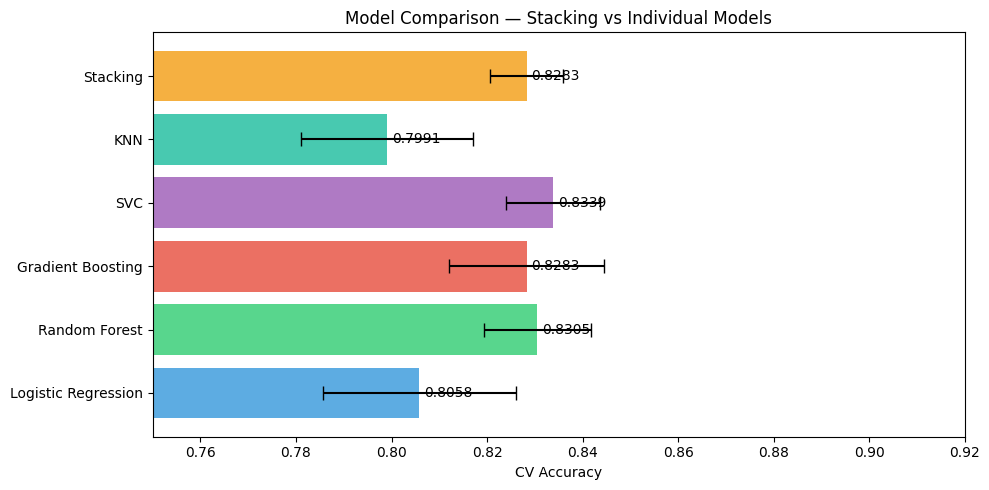

In [6]:
names  = list(results.keys())
means  = [results[n].mean() for n in names]
stds   = [results[n].std()  for n in names]
colors = ['#3498db','#2ecc71','#e74c3c','#9b59b6','#1abc9c','#f39c12']

plt.figure(figsize=(10, 5))
bars = plt.barh(names, means, xerr=stds, color=colors, alpha=0.8, capsize=5)
plt.xlabel('CV Accuracy')
plt.title('Model Comparison — Stacking vs Individual Models')
plt.xlim(0.75, 0.92)

for bar, mean in zip(bars, means):
    plt.text(mean + 0.001, bar.get_y() + bar.get_height()/2,
             f'{mean:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

In [7]:
# Retrain on all 891 rows
stacking_clf.fit(X, y)

predictions = stacking_clf.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_ids,
    'Survived'   : predictions
})

submission.to_csv('submission.csv', index=False)
print('submission.csv saved ✅')
print(f'Predicted {predictions.sum()} survivors out of {len(predictions)}')
submission.head(10)

submission.csv saved ✅
Predicted 161 survivors out of 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0
